# GPU representative grouper timing analysis

This notebook reads only the side-by-side GPU representative-grouper benchmark output. Performance plots include only rows that completed with exact all-field parity. Safety skips, other failures, and parity failures remain visible as status markers/counts and in the compact table.

In [17]:
import csv
import os
from collections import Counter
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

RESULT_DIRECTORY_NAME = "results_gaussian_corruption_gpu_representative_grouper_timing"
configured = os.environ.get("PIRATE_GPU_REPRESENTATIVE_GROUPER_RESULTS")
if configured:
    RESULTS_DIR = Path(configured).expanduser()
else:
    result_candidates = (
        Path.cwd() / "peakfinder_tests" / RESULT_DIRECTORY_NAME,
        Path.cwd() / RESULT_DIRECTORY_NAME,
    )
    RESULTS_DIR = next(
        (path for path in result_candidates if (path / "trials.csv").is_file()),
        result_candidates[0],
    )
TRIALS_CSV = RESULTS_DIR / "trials.csv"
if not TRIALS_CSV.is_file():
    raise FileNotFoundError(
        f"Missing {TRIALS_CSV}. Run the GPU representative-grouper benchmark "
        "or set PIRATE_GPU_REPRESENTATIVE_GROUPER_RESULTS."
    )

with TRIALS_CSV.open(newline="", encoding="utf-8") as stream:
    reader = csv.DictReader(stream)
    trial_fields = tuple(reader.fieldnames or ())
    raw_trials = list(reader)
if not trial_fields or len(trial_fields) != len(set(trial_fields)):
    raise ValueError(f"{TRIALS_CSV}: missing or duplicate CSV columns")
if not raw_trials:
    raise ValueError(f"{TRIALS_CSV}: result table is empty")
print(f"Loaded {len(raw_trials)} rows from {TRIALS_CSV.resolve()}")

Loaded 400 rows from /home/mtrudu/src/pirate-updated/peakfinder_tests/results_gaussian_corruption_gpu_representative_grouper_timing/trials.csv


In [18]:
REQUIRED_COLUMNS = {
    "trial",
    "target_corruption_percent",
    "total_pixels_above_threshold",
    "total_peakfinder_candidates",
    "decoder_wall_ms",
    "total_decoded_candidates",
    "partition_count",
    "largest_partition",
    "total_grouped_events",
    "production_grouper_wall_ms",
    "experimental_grouper_wall_ms",
    "production_candidates_per_second",
    "experimental_candidates_per_second",
    "production_over_experimental_speedup",
    "exact_parity_verified",
    "status",
    "failure_reason",
}
missing = sorted(REQUIRED_COLUMNS - set(trial_fields))
if missing:
    raise ValueError(f"Benchmark trials.csv is missing required columns: {missing}")

INTEGER_COLUMNS = {
    "trial", "total_pixels_above_threshold", "total_peakfinder_candidates",
    "total_decoded_candidates", "partition_count", "largest_partition",
    "total_grouped_events", "exact_parity_verified",
}
FLOAT_COLUMNS = {
    "target_corruption_percent", "decoder_wall_ms",
    "production_grouper_wall_ms", "experimental_grouper_wall_ms",
    "production_candidates_per_second", "experimental_candidates_per_second",
    "production_over_experimental_speedup",
}

def optional_number(value, converter, context):
    text = "" if value is None else str(value).strip()
    if not text:
        return None
    try:
        result = converter(text)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"{context}: invalid numeric value {value!r}") from exc
    if isinstance(result, float) and not np.isfinite(result):
        raise ValueError(f"{context}: non-finite numeric value {value!r}")
    return result

def classify_status(value):
    value = str(value)
    if value == "completed":
        return "completed"
    if value == "skipped_candidate_safety_limit":
        return "safety-skipped"
    if value == "failed_parity":
        return "parity-failed"
    return "failed"

trials = []
for line_number, raw in enumerate(raw_trials, start=2):
    row = dict(raw)
    for column in INTEGER_COLUMNS:
        row[column] = optional_number(row[column], int, f"trials.csv:{line_number}:{column}")
    for column in FLOAT_COLUMNS:
        row[column] = optional_number(row[column], float, f"trials.csv:{line_number}:{column}")
    row["analysis_status"] = classify_status(row["status"])
    trials.append(row)

STATUS_ORDER = ("completed", "safety-skipped", "failed", "parity-failed")
STATUS_STYLE = {
    "completed": {"color": "#2ca02c", "marker": "o", "background": "#e8f5e9"},
    "safety-skipped": {"color": "#d99a00", "marker": "x", "background": "#fff8e1"},
    "failed": {"color": "#d62728", "marker": "^", "background": "#ffebee"},
    "parity-failed": {"color": "#9467bd", "marker": "P", "background": "#f3e5f5"},
}
completed = [row for row in trials if row["analysis_status"] == "completed"]
if any(row["exact_parity_verified"] != 1 for row in completed):
    raise ValueError("A completed row does not claim exact all-field parity")
if any(
    row["production_over_experimental_speedup"] is not None
    for row in trials if row["analysis_status"] != "completed"
):
    raise ValueError("A non-completed row improperly reports a speedup")
status_counts = Counter(row["analysis_status"] for row in trials)
print("Row status: " + ", ".join(
    f"{status}={status_counts.get(status, 0)}" for status in STATUS_ORDER
))

def finite_pairs(rows, x_column, y_column):
    pairs = [
        (float(row[x_column]), float(row[y_column]))
        for row in rows
        if row.get(x_column) is not None and row.get(y_column) is not None
        and np.isfinite(float(row[x_column])) and np.isfinite(float(row[y_column]))
    ]
    if not pairs:
        return np.empty(0), np.empty(0)
    return np.asarray(pairs, dtype=np.float64).T

def scatter_completed(ax, x_column, y_column, label, color, marker):
    x, y = finite_pairs(completed, x_column, y_column)
    if x.size:
        ax.scatter(x, y, label=label, color=color, marker=marker, alpha=0.8)

def add_status_context(ax, x_column):
    for status in STATUS_ORDER[1:]:
        values = [
            float(row[x_column]) for row in trials
            if row["analysis_status"] == status and row.get(x_column) is not None
        ]
        if values:
            style = STATUS_STYLE[status]
            ax.scatter(
                np.asarray(values), np.full(len(values), 1.02),
                transform=ax.get_xaxis_transform(), clip_on=False,
                color=style["color"], marker=style["marker"], s=45,
                label=f"{status} (excluded from performance series)",
            )
    count_text = "All recorded rows: " + ", ".join(
        f"{status}={status_counts.get(status, 0)}" for status in STATUS_ORDER
    )
    ax.text(0.0, -0.20, count_text, transform=ax.transAxes, fontsize=9)

def finish_plot(ax, *, title, xlabel, ylabel, x_symlog=True, y_symlog=False):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if x_symlog:
        ax.set_xscale("symlog", linthresh=1.0)
    if y_symlog:
        ax.set_yscale("symlog", linthresh=1.0)
    ax.grid(True, alpha=0.25)
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend()
    ax.figure.tight_layout(rect=(0.0, 0.08, 1.0, 1.0))

Row status: completed=400, safety-skipped=0, failed=0, parity-failed=0


## Performance scope

These figures are descriptive views of completed, exact-parity rows in this output directory. They do not establish a general speed improvement. A small trial count is useful for correctness and preliminary scaling checks, but uncertainty should be assessed before making a production claim.

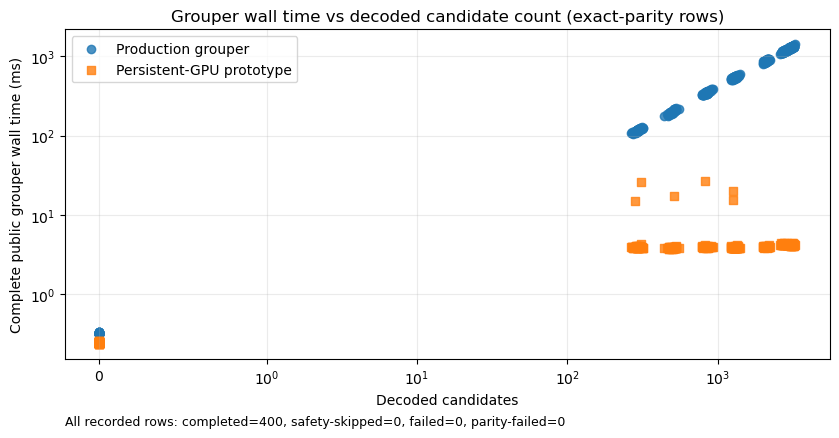

In [19]:
# 1. Production and experimental wall time versus decoded candidates.
fig, ax = plt.subplots(figsize=(8.5, 5.0))
scatter_completed(ax, "total_decoded_candidates", "production_grouper_wall_ms", "Production grouper", "#1f77b4", "o")
scatter_completed(ax, "total_decoded_candidates", "experimental_grouper_wall_ms", "Persistent-GPU prototype", "#ff7f0e", "s")
add_status_context(ax, "total_decoded_candidates")
finish_plot(ax, title="Grouper wall time vs decoded candidate count (exact-parity rows)", xlabel="Decoded candidates", ylabel="Complete public grouper wall time (ms)", y_symlog=True)
plt.show()

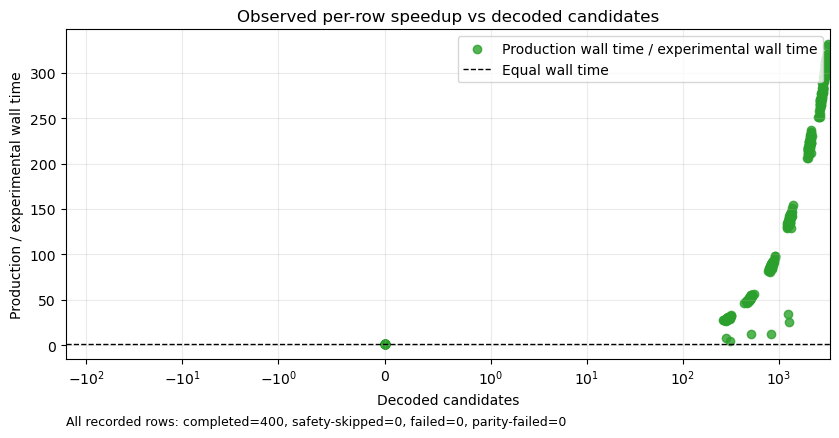

In [20]:
# 2. Per-row production/experimental speedup versus decoded candidates.
fig, ax = plt.subplots(figsize=(8.5, 5.0))
scatter_completed(ax, "total_decoded_candidates", "production_over_experimental_speedup", "Production wall time / experimental wall time", "#2ca02c", "o")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.0, label="Equal wall time")
add_status_context(ax, "total_decoded_candidates")
finish_plot(ax, title="Observed per-row speedup vs decoded candidates", xlabel="Decoded candidates", ylabel="Production / experimental wall time")
plt.show()

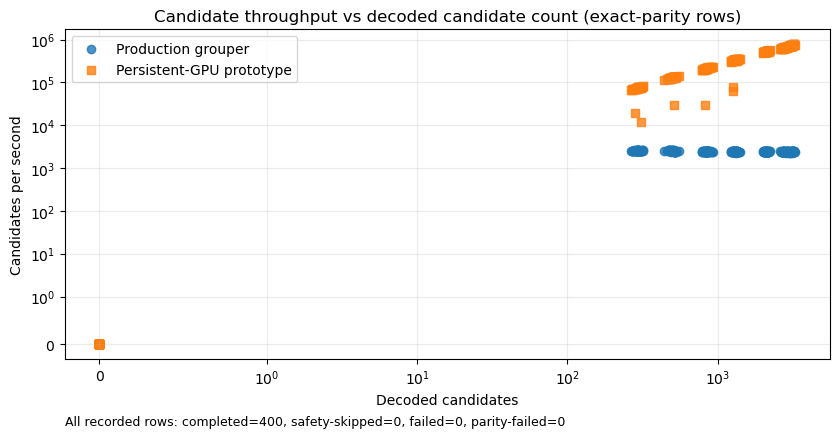

In [21]:
# 3. Candidate throughput for both implementations.
fig, ax = plt.subplots(figsize=(8.5, 5.0))
scatter_completed(ax, "total_decoded_candidates", "production_candidates_per_second", "Production grouper", "#1f77b4", "o")
scatter_completed(ax, "total_decoded_candidates", "experimental_candidates_per_second", "Persistent-GPU prototype", "#ff7f0e", "s")
add_status_context(ax, "total_decoded_candidates")
finish_plot(ax, title="Candidate throughput vs decoded candidate count (exact-parity rows)", xlabel="Decoded candidates", ylabel="Candidates per second", y_symlog=True)
plt.show()

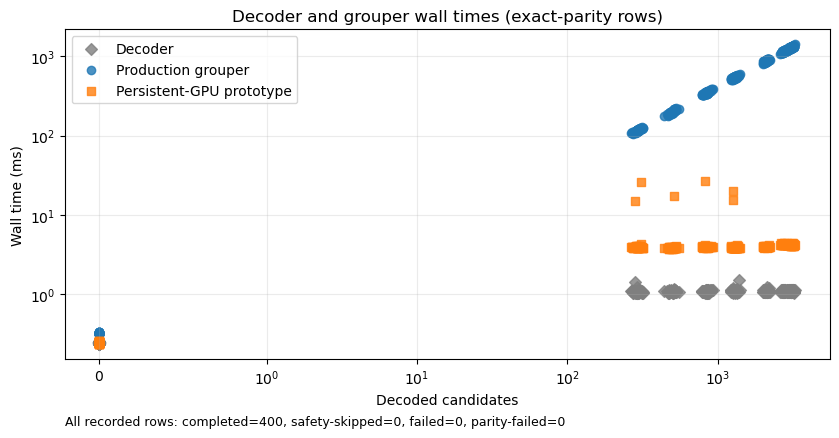

In [22]:
# 4. Decoder time compared with both complete grouper times.
fig, ax = plt.subplots(figsize=(8.5, 5.0))
scatter_completed(ax, "total_decoded_candidates", "decoder_wall_ms", "Decoder", "#7f7f7f", "D")
scatter_completed(ax, "total_decoded_candidates", "production_grouper_wall_ms", "Production grouper", "#1f77b4", "o")
scatter_completed(ax, "total_decoded_candidates", "experimental_grouper_wall_ms", "Persistent-GPU prototype", "#ff7f0e", "s")
add_status_context(ax, "total_decoded_candidates")
finish_plot(ax, title="Decoder and grouper wall times (exact-parity rows)", xlabel="Decoded candidates", ylabel="Wall time (ms)", y_symlog=True)
plt.show()

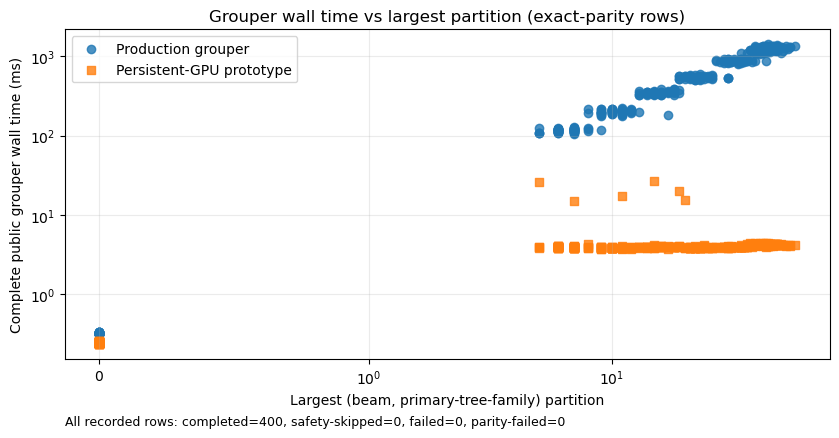

In [23]:
# 5. Both grouper times versus the largest independent partition.
fig, ax = plt.subplots(figsize=(8.5, 5.0))
scatter_completed(ax, "largest_partition", "production_grouper_wall_ms", "Production grouper", "#1f77b4", "o")
scatter_completed(ax, "largest_partition", "experimental_grouper_wall_ms", "Persistent-GPU prototype", "#ff7f0e", "s")
add_status_context(ax, "largest_partition")
finish_plot(ax, title="Grouper wall time vs largest partition (exact-parity rows)", xlabel="Largest (beam, primary-tree-family) partition", ylabel="Complete public grouper wall time (ms)", y_symlog=True)
plt.show()

## Compact trial table

The final column combines execution status and parity state. Blank timing or speedup cells are shown as em dashes; they are not imputed.

In [24]:
def parity_status_label(row):
    status = row["analysis_status"]
    if status == "completed":
        return "completed / exact parity verified"
    if status == "safety-skipped":
        return "safety-skipped / comparison not run"
    if status == "parity-failed":
        return "parity-failed / exact mismatch"
    return f"failed / {row['status']}"

TABLE_COLUMNS = (
    ("target_corruption_percent", "corruption %", lambda value: f"{value:.6g}"),
    ("total_pixels_above_threshold", "above-threshold pixels", lambda value: f"{value:d}"),
    ("total_peakfinder_candidates", "bowtie survivors", lambda value: f"{value:d}"),
    ("total_decoded_candidates", "decoded candidates", lambda value: f"{value:d}"),
    ("largest_partition", "largest partition", lambda value: f"{value:d}"),
    ("total_grouped_events", "grouped events", lambda value: f"{value:d}"),
    ("production_grouper_wall_ms", "production ms", lambda value: f"{value:.6g}"),
    ("experimental_grouper_wall_ms", "experimental ms", lambda value: f"{value:.6g}"),
    ("production_over_experimental_speedup", "speedup", lambda value: f"{value:.4g}x"),
)

def formatted(value, formatter):
    return "—" if value is None else formatter(value)

header = "".join(f"<th>{escape(label)}</th>" for _, label, _ in TABLE_COLUMNS)
header += "<th>parity/status</th>"
body = []
for row in sorted(trials, key=lambda item: (item["target_corruption_percent"], item["trial"])):
    cells = "".join(
        f"<td>{escape(formatted(row[field], formatter))}</td>"
        for field, _, formatter in TABLE_COLUMNS
    )
    status = row["analysis_status"]
    reason = row.get("failure_reason") or ""
    cells += (
        f"<td title='{escape(reason)}'>{escape(parity_status_label(row))}</td>"
    )
    body.append(
        f"<tr style='background:{STATUS_STYLE[status]['background']}'>{cells}</tr>"
    )

table_html = f"""
<div style="max-height:520px; overflow:auto; border:1px solid #bbb">
<table style="border-collapse:collapse; width:100%; font-size:90%">
<thead style="position:sticky; top:0; background:white"><tr>{header}</tr></thead>
<tbody>{''.join(body)}</tbody>
</table>
</div>
<style>
table th, table td {{ padding:4px 7px; border:1px solid #ccc; text-align:right; }}
table th:last-child, table td:last-child {{ text-align:left; white-space:nowrap; }}
</style>
"""
display(HTML(table_html))

corruption %,above-threshold pixels,bowtie survivors,decoded candidates,largest partition,grouped events,production ms,experimental ms,speedup,parity/status
0,0,0,0,0,0,0.557918,0.449318,1.242x,completed / exact parity verified
0,0,0,0,0,0,0.560987,0.454877,1.233x,completed / exact parity verified
0,0,0,0,0,0,0.561852,0.472255,1.19x,completed / exact parity verified
0,0,0,0,0,0,0.572175,0.456433,1.254x,completed / exact parity verified
0,0,0,0,0,0,0.555211,0.456036,1.217x,completed / exact parity verified
0,0,0,0,0,0,0.56416,0.458351,1.231x,completed / exact parity verified
0,0,0,0,0,0,0.567179,0.459552,1.234x,completed / exact parity verified
0,0,0,0,0,0,0.557917,0.45477,1.227x,completed / exact parity verified
0,0,0,0,0,0,0.573014,0.46001,1.246x,completed / exact parity verified
0,0,0,0,0,0,0.563385,0.45527,1.237x,completed / exact parity verified
